# 05-1 🎓 연습문제


## 데이터 준비하기

In [7]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

wine = pd.read_csv("./data/wine.csv")

X = wine[['alcohol', 'sugar', 'pH']]
y = wine['class']

train_input, test_input, train_target, test_target = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### 문제 1

DecisionTreeClassifier로 모델을 만들고 정확도를 출력하시오.

In [8]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(train_input, train_target)

print("train acc:", dt.score(train_input, train_target))
print("test acc :", dt.score(test_input, test_target))

train acc: 0.996921300750433
test acc : 0.8584615384615385


In [9]:
dt.classes_

# 타깃 클래스가 0과 1 두 개라는 뜻

array([0., 1.])

In [10]:
#feature 이름 확인
dt.feature_names_in_

array(['alcohol', 'sugar', 'pH'], dtype=object)

### 문제 2

max_depth=3으로 제한하고 정확도를 비교하시오.

In [15]:
dt_depth3 = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_depth3.fit(train_input, train_target)

print("=== max_depth=None (기본) ===")
print("train acc:", dt.score(train_input, train_target))
print("test acc :", dt.score(test_input, test_target))

print("\n=== max_depth=3 ===")
print("train acc:", dt_depth3.score(train_input, train_target))
print("test acc :", dt_depth3.score(test_input, test_target))

=== max_depth=None (기본) ===
train acc: 0.996921300750433
test acc : 0.8584615384615385

=== max_depth=3 ===
train acc: 0.8454877814123533
test acc : 0.8415384615384616


### 문제 3

결정트리를 시각화하시오.

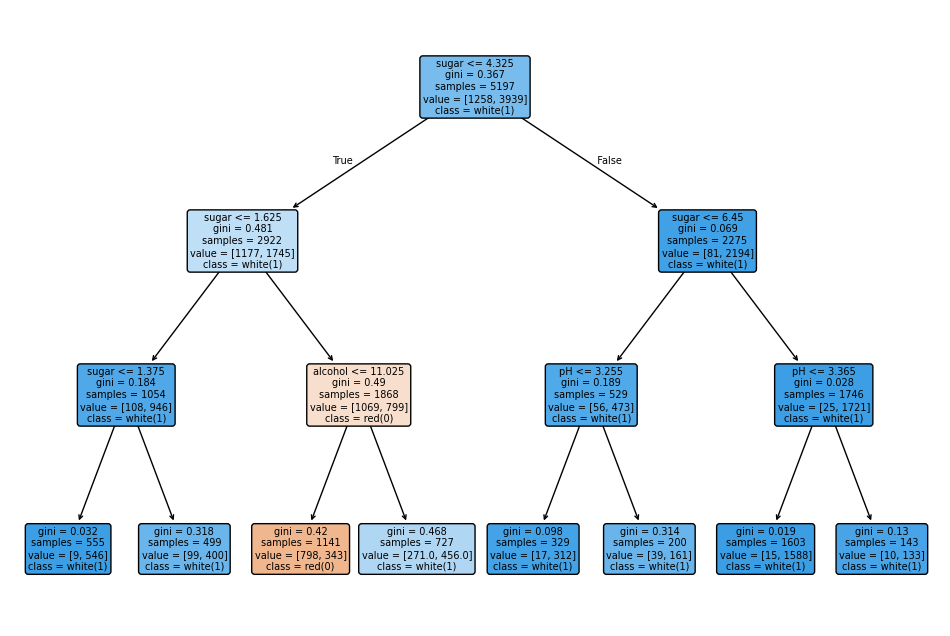

In [12]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(12, 8))
plot_tree(
    dt_depth3,
    filled=True,
    feature_names=['alcohol', 'sugar', 'pH'],
    class_names=['red(0)', 'white(1)'],
    rounded=True 
)
plt.show()

### 문제 4

feature_importances_를 출력하고

가장 중요한 특성을 찾으시오.

In [13]:
dt.feature_names_in_

array(['alcohol', 'sugar', 'pH'], dtype=object)

In [14]:
import numpy as np

importances = dt_depth3.feature_importances_
features = dt.feature_names_in_

print("feature_importances_:", importances)

most_important = features[np.argmax(importances)]
print("가장 중요한 특성:", most_important)

feature_importances_: [0.12345626 0.86862934 0.0079144 ]
가장 중요한 특성: sugar


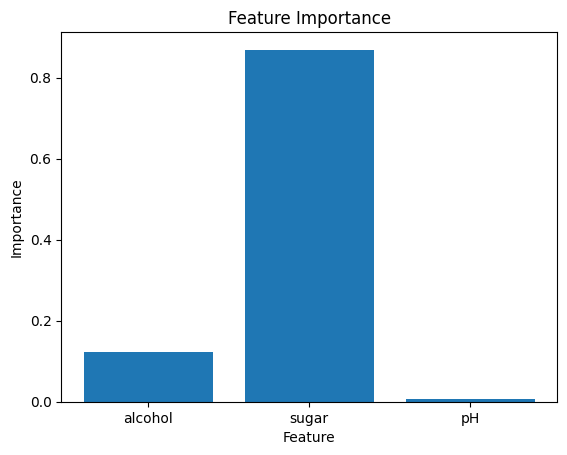

In [16]:
import matplotlib.pyplot as plt
features = dt.feature_names_in_
importances = dt_depth3.feature_importances_

plt.bar(features, importances)

plt.title("Feature Importance")
plt.xlabel("Feature")
plt.ylabel("Importance")

plt.show()
